# Dataset Inspector
Exploratory inspection of `spam_email.csv` — the primary dataset for this project.

Covers: shape & dtypes, missing values, duplicates, class balance, text-length distribution, sample rows, top tokens, and structural feature preview.

In [1]:
import os
import re
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Path relative to this notebook (notebooks/ → data/raw/)
DATA_PATH = os.path.join('../data/processed/spam_email.csv')
print(f"Dataset path : {os.path.abspath(DATA_PATH)}")
print(f"File exists  : {os.path.exists(DATA_PATH)}")

Dataset path : c:\Users\Chanheng Menh\Documents\Spring-2026\Machine-Learning\final-project\data\processed\spam_email.csv
File exists  : True


---
## 1 · Load & Basic Info

In [2]:
try:
    df = pd.read_csv(DATA_PATH, encoding='utf-8', on_bad_lines='skip')
except Exception:
    df = pd.read_csv(DATA_PATH, encoding='latin-1', on_bad_lines='skip')

# Normalise column names to lowercase
df.columns = [c.strip().lower() for c in df.columns]

# Ensure standard column names
if 'label' not in df.columns or 'text' not in df.columns:
    # Auto-detect
    text_col  = next((c for c in df.columns if any(k in c for k in ('text','body','message','email'))), None)
    label_col = next((c for c in df.columns if any(k in c for k in ('label','spam','class','type'))), None)
    if text_col and label_col:
        df = df.rename(columns={text_col: 'text', label_col: 'label'})
    else:
        raise ValueError(f"Cannot detect text/label columns. Found: {list(df.columns)}")

# Normalise labels → int (1=spam, 0=ham)
def to_binary(s):
    v = str(s).strip().lower()
    if v in {'1', 'spam', 'yes', 'junk'}:
        return 1
    if v in {'0', 'ham', 'no', 'normal', 'notspam'}:
        return 0
    return np.nan

df['label'] = df['label'].apply(to_binary)
df = df[['text', 'label']].dropna().copy()
df['text']  = df['text'].astype(str)
df['label'] = df['label'].astype(int)

print("=== Raw Shape ===")
print(f"  Rows    : {len(df):,}")
print(f"  Columns : {list(df.columns)}\n")

print("=== dtypes ===")
print(df.dtypes.to_string(), "\n")

print("=== Missing Values ===")
print(df.isnull().sum().to_string(), "\n")

dup_count = df.duplicated(subset=['text']).sum()
print(f"=== Exact-Text Duplicates : {dup_count:,} ({dup_count/len(df)*100:.1f}%) ===")
df_clean = df.drop_duplicates(subset=['text']).reset_index(drop=True)
print(f"  After dedup: {len(df_clean):,} rows")

=== Raw Shape ===
  Rows    : 80,000
  Columns : ['text', 'label']

=== dtypes ===
text     object
label     int64 

=== Missing Values ===
text     0
label    0 

=== Exact-Text Duplicates : 0 (0.0%) ===
  After dedup: 80,000 rows


---
## 2 · Class Distribution

=== Class Counts (after dedup) ===
  Ham  (0) :   42,291  (52.9%)
  Spam (1) :   37,709  (47.1%)
  Total    :   80,000
  Imbalance ratio (ham:spam) = 1.12:1


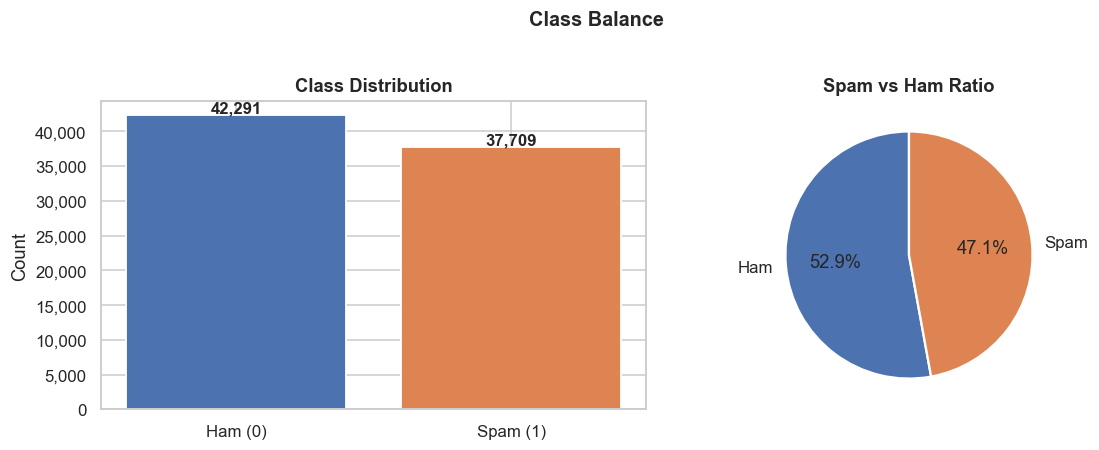

In [3]:
counts = df_clean['label'].value_counts().sort_index()
spam_n, ham_n = counts.get(1, 0), counts.get(0, 0)
total = len(df_clean)

print("=== Class Counts (after dedup) ===")
print(f"  Ham  (0) : {ham_n:>8,}  ({ham_n/total*100:.1f}%)")
print(f"  Spam (1) : {spam_n:>8,}  ({spam_n/total*100:.1f}%)")
print(f"  Total    : {total:>8,}")
print(f"  Imbalance ratio (ham:spam) = {ham_n/spam_n:.2f}:1" if spam_n else "")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
bars = axes[0].bar(['Ham (0)', 'Spam (1)'], [ham_n, spam_n],
                   color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.2)
for bar, v in zip(bars, [ham_n, spam_n]):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + total*0.005,
                 f'{v:,}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
axes[1].pie([ham_n, spam_n], labels=['Ham', 'Spam'],
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Spam vs Ham Ratio', fontweight='bold')

plt.suptitle('Class Balance', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 3 · Text Length Distribution

=== Text Length Summary by Class ===
      word_count                                                    char_count                                                        
           count   mean     std  min   25%    50%    75%        max      count    mean      std  min    25%    50%     75%         max
label                                                                                                                                 
0        42291.0  351.1  7749.2  1.0  65.0  149.0  310.0  1585483.0    42291.0  2289.1  56199.0  2.0  415.5  946.0  1961.0  11510306.0
1        37709.0  209.9   338.6  1.0  47.0  106.0  239.0    24895.0    37709.0  1405.9   2340.5  1.0  308.0  674.0  1561.0    141261.0


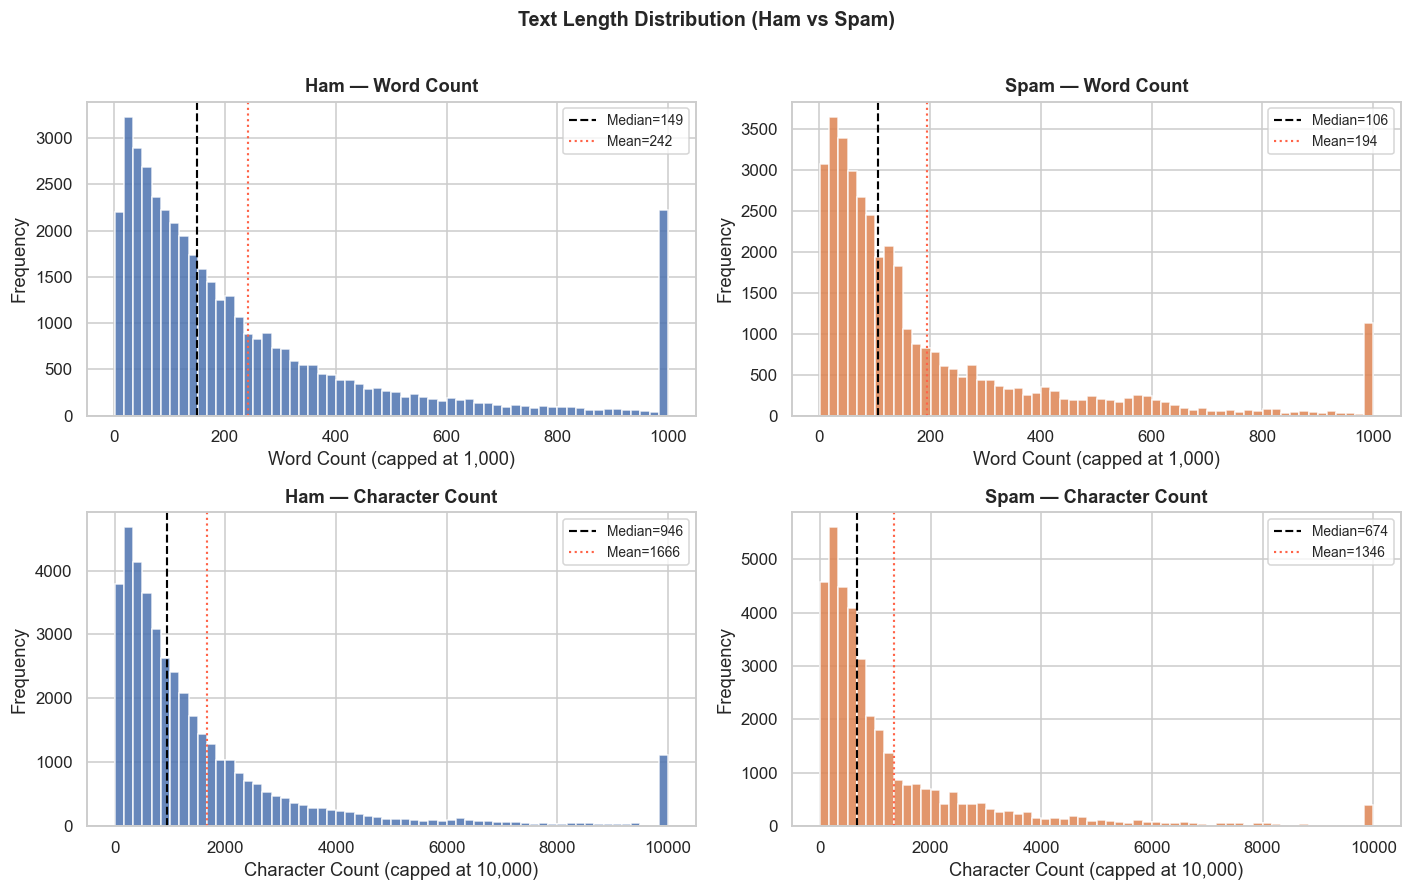

In [4]:
df_clean['word_count'] = df_clean['text'].str.split().str.len()
df_clean['char_count'] = df_clean['text'].str.len()

print("=== Text Length Summary by Class ===")
print(df_clean.groupby('label')[['word_count', 'char_count']].describe().round(1).to_string())

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for row, (col, xlabel, cap) in enumerate([
    ('word_count', 'Word Count', 1000),
    ('char_count', 'Character Count', 10000),
]):
    for ax, cls, label, colour in zip(axes[row], [0, 1], ['Ham', 'Spam'], ['#4C72B0', '#DD8452']):
        subset = df_clean[df_clean['label'] == cls][col].clip(upper=cap)
        ax.hist(subset, bins=60, color=colour, alpha=0.85, edgecolor='white')
        med = subset.median()
        mn  = subset.mean()
        ax.axvline(med, color='black',  linestyle='--', lw=1.4, label=f'Median={med:.0f}')
        ax.axvline(mn,  color='tomato', linestyle=':',  lw=1.4, label=f'Mean={mn:.0f}')
        ax.set_title(f'{label} — {xlabel}', fontweight='bold')
        ax.set_xlabel(f'{xlabel} (capped at {cap:,})')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=9)

plt.suptitle('Text Length Distribution (Ham vs Spam)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 4 · Sample Rows

In [5]:
pd.set_option('display.max_colwidth', 120)

print("=== 5 Sample HAM emails ===")
display(df_clean[df_clean['label'] == 0][['text', 'word_count']].sample(5, random_state=42))

print("\n=== 5 Sample SPAM emails ===")
display(df_clean[df_clean['label'] == 1][['text', 'word_count']].sample(5, random_state=42))

pd.reset_option('display.max_colwidth')

=== 5 Sample HAM emails ===


,text,word_count
27004,the attached schedule is for tuesday june escapenumber associated text files have been posted to sparky michael r fr...,38
64053,that federal funds were used to develop norvir was at the crux of a escapenumber request by consumer advocacy group ...,819
27660,thank you rod,3
2686,carrie ive speaking sara shackleton legal would prefer view requested contracts office keeps files would avoid dupli...,377
38506,"another article i thought you might find interesting .\nregards ,\neugenio\nreview of energy policies kicks off\nasa...",356



=== 5 Sample SPAM emails ===


,text,word_count
71953,nu xp titles released on may escapenumber escapenumber escapenumber escapenumber msk escapenumber adobe photoshop cs...,393
72412,jesus christ without us but and old now a days come running to escapenumber worship our blessed god the father escap...,127
20102,nomad international inc ndin multi national internet communications company developing cost effective telecommunicat...,521
5924,create a second source of income using google choose from thousands of different products on google to promote and s...,140
3352,escapenumber íáñ escapenumber ç íïóë×á éîæïòíáãéïîîùå óéóôåíù äìñ õðòá÷ìåîþåóëïçï õþåôá ðòïâìåíù ÷ùâïòá é ÷îåäòåîéñ ...,642


---
## 5 · Structural Feature Preview

The 9 structural features used by the pipeline (`src/features.py`), computed on the raw text.

=== Structural Feature Means by Class ===


,url_count,email_addr_count,special_char_ratio,uppercase_ratio,html_tag_count,email_length,digit_ratio,exclamation_count,dollar_count
label,,,,,,,,,
Ham,0.1060,0.0,0.0005,0.0,0.0,2289.1226,0.0068,0.1059,0.1386
Spam,0.0114,0.0,0.0008,0.0,0.0,1405.8890,0.0042,0.2606,0.2071


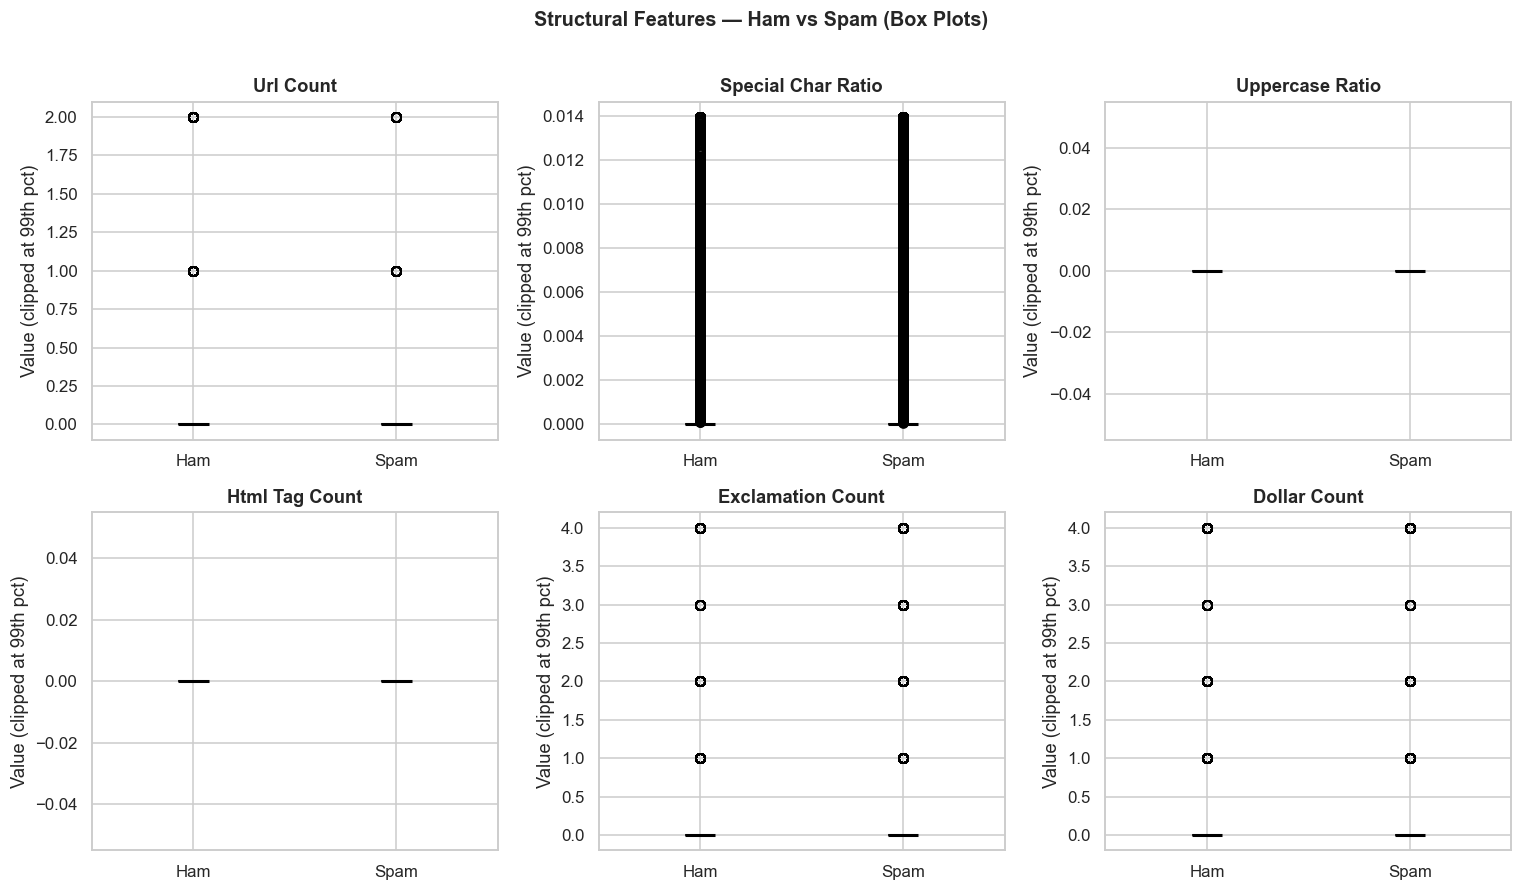

In [6]:
def extract_structural(text):
    if not isinstance(text, str):
        text = ""
    length = max(len(text), 1)
    return {
        'url_count':          len(re.findall(r'http\S+|www\S+', text)),
        'email_addr_count':   len(re.findall(r'\S+@\S+', text)),
        'special_char_ratio': len(re.findall(r'[!$%@#*]', text)) / length,
        'uppercase_ratio':    sum(1 for c in text if c.isupper()) / length,
        'html_tag_count':     len(re.findall(r'<[^>]+>', text)),
        'email_length':       len(text),
        'digit_ratio':        sum(1 for c in text if c.isdigit()) / length,
        'exclamation_count':  text.count('!'),
        'dollar_count':       text.count('$'),
    }

struct_df = pd.DataFrame([extract_structural(t) for t in df_clean['text']])
struct_df['label'] = df_clean['label'].values

print("=== Structural Feature Means by Class ===")
display(struct_df.groupby('label').mean().round(4).rename(index={0: 'Ham', 1: 'Spam'}))

# Box plots for top discriminative features
features_to_plot = ['url_count', 'special_char_ratio', 'uppercase_ratio',
                    'html_tag_count', 'exclamation_count', 'dollar_count']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.flat, features_to_plot):
    data_ham  = struct_df[struct_df['label'] == 0][feat].clip(upper=struct_df[feat].quantile(0.99))
    data_spam = struct_df[struct_df['label'] == 1][feat].clip(upper=struct_df[feat].quantile(0.99))
    ax.boxplot([data_ham, data_spam], labels=['Ham', 'Spam'],
               patch_artist=True,
               boxprops=dict(facecolor='#c9d9f0'),
               medianprops=dict(color='black', lw=2))
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.set_ylabel('Value (clipped at 99th pct)')

plt.suptitle('Structural Features — Ham vs Spam (Box Plots)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 6 · Top Tokens per Class

Raw token frequency counts (before any stemming/stopword removal) to see what words dominate each class.

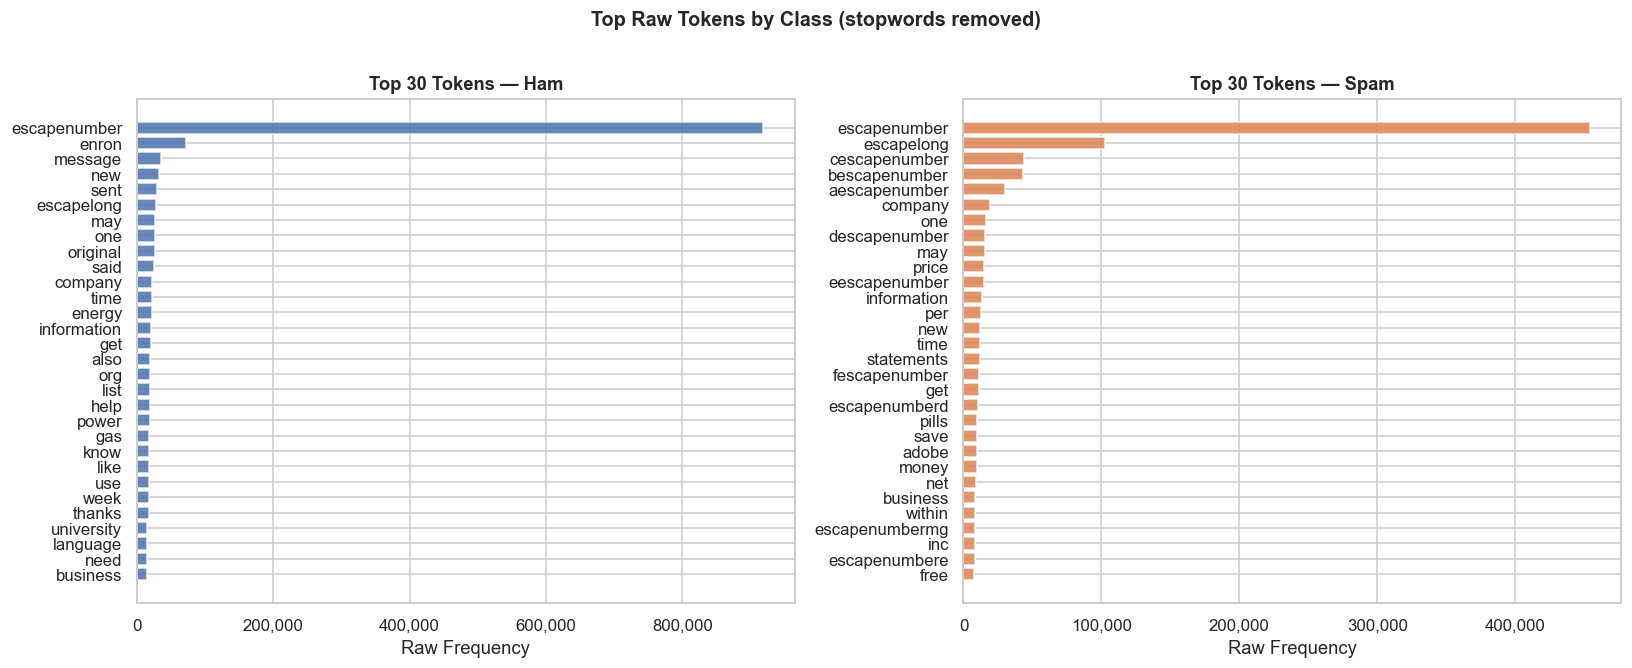

In [8]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

STOP = set(stopwords.words('english'))
# Add very common noise words that appear in both classes
STOP.update({'subject', 'email', 'mail', 'would', 'could', 'please',
             'http', 'www', 'com', 'nbsp', 'thank', 'regards'})

def top_tokens(texts, n=30):
    counter = Counter()
    for t in texts:
        tokens = re.sub(r'[^a-z\s]', ' ', str(t).lower()).split()
        counter.update(tok for tok in tokens if tok not in STOP and len(tok) > 2)
    return counter.most_common(n)

ham_tokens  = top_tokens(df_clean[df_clean['label'] == 0]['text'])
spam_tokens = top_tokens(df_clean[df_clean['label'] == 1]['text'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, tokens, label, colour in zip(axes,
                                      [ham_tokens, spam_tokens],
                                      ['Ham', 'Spam'],
                                      ['#4C72B0', '#DD8452']):
    words, counts = zip(*tokens)
    ax.barh(list(words)[::-1], list(counts)[::-1], color=colour, alpha=0.85)
    ax.set_title(f'Top 30 Tokens — {label}', fontweight='bold')
    ax.set_xlabel('Raw Frequency')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Top Raw Tokens by Class (stopwords removed)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 7 · Summary

In [9]:
print("=" * 55)
print("  DATASET INSPECTION SUMMARY")
print("=" * 55)
print(f"  File              : spam_Emails_data.csv")
print(f"  Raw rows          : {len(df):,}")
print(f"  After dedup       : {len(df_clean):,}  (removed {len(df)-len(df_clean):,})")
print(f"  Ham  (0)          : {ham_n:,}  ({ham_n/total*100:.1f}%)")
print(f"  Spam (1)          : {spam_n:,}  ({spam_n/total*100:.1f}%)")
print(f"  Imbalance ratio   : {ham_n/spam_n:.2f}:1 (ham:spam)")
print(f"  Median word count : Ham={df_clean[df_clean['label']==0]['word_count'].median():.0f}  "
      f"Spam={df_clean[df_clean['label']==1]['word_count'].median():.0f}")
print(f"  Missing values    : {df_clean.isnull().sum().sum()}")
print("=" * 55)

  DATASET INSPECTION SUMMARY
  File              : spam_Emails_data.csv
  Raw rows          : 80,000
  After dedup       : 80,000  (removed 0)
  Ham  (0)          : 42,291  (52.9%)
  Spam (1)          : 37,709  (47.1%)
  Imbalance ratio   : 1.12:1 (ham:spam)
  Median word count : Ham=149  Spam=106
  Missing values    : 0
